<style>
h1, h1 *, 
h2, h2 *, 
h3, h3 *, 
h4, h4 *, 
h5, h5 *, 
h6, h6 * {
  font-family: "Times New Roman", Times, serif !important;

</style>

### **Customer Segmentation**

---

In [1]:
import sys
!{sys.executable} -m pip install streamlit

In [2]:
import sys
!{sys.executable} -m pip install joblib

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('Customer Segmentation - Dataset.csv')
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [5]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [6]:
df.shape

(2240, 29)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [8]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [9]:
df.dropna(inplace = True)

In [10]:
df.isna().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2216.0,5588.353339,3249.376275,0.0,2814.75,5458.5,8421.75,11191.0
Year_Birth,2216.0,1968.820397,11.985554,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2216.0,0.441787,0.536896,0.0,0.00,0.0,1.00,2.0
Teenhome,2216.0,0.505415,0.544181,0.0,0.00,0.0,1.00,2.0
Recency,2216.0,49.012635,28.948352,0.0,24.00,49.0,74.00,99.0
MntWines,2216.0,305.091606,337.327920,0.0,24.00,174.5,505.00,1493.0
MntFruits,2216.0,26.356047,39.793917,0.0,2.00,8.0,33.00,199.0
MntMeatProducts,2216.0,166.995939,224.283273,0.0,16.00,68.0,232.25,1725.0
MntFishProducts,2216.0,37.637635,54.752082,0.0,3.00,12.0,50.00,259.0


In [12]:
df['Education'].value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

In [13]:
df['Marital_Status'].value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [14]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   object        
 3   Marital_Status       2216 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[ns]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2216 non-null   i

In [15]:
df['Age'] = 2026 - df['Year_Birth']
df['Age']

0       69
1       72
2       61
3       42
4       45
        ..
2235    59
2236    80
2237    45
2238    70
2239    72
Name: Age, Length: 2216, dtype: int64

In [16]:
df['Total Children'] = df['Kidhome'] + df['Teenhome']
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,0,3,11,1,69,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,3,11,0,72,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,0,3,11,0,61,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,0,3,11,0,42,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,0,3,11,0,45,1


In [17]:
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 
              'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['Total_Spending'] = df[spend_cols].sum(axis = 1)
df['Total_Spending']

0       1617
1         27
2        776
3         53
4        422
        ... 
2235    1341
2236     444
2237    1241
2238     843
2239     172
Name: Total_Spending, Length: 2216, dtype: int64

In [18]:
df['Customer_Since'] = (pd.Timestamp('today') - df['Dt_Customer']).dt.days
df['Customer_Since']

0       5049
1       4499
2       4698
3       4525
4       4547
        ... 
2235    4767
2236    4405
2237    4541
2238    4542
2239    5008
Name: Customer_Since, Length: 2216, dtype: int64

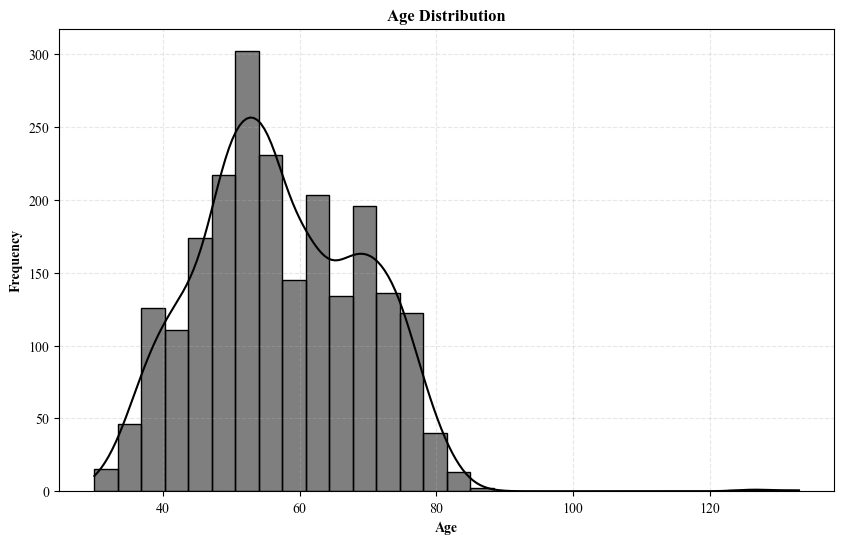

In [19]:
from matplotlib import rcParams
rcParams['font.family'] = 'Times New Roman'

fig, ax = plt.subplots(figsize = (10, 6))
sns.histplot(df['Age'], bins = 30, kde = True, color = 'black', edgecolor = 'black', ax = ax)
ax.set_title('Age Distribution', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Age', fontweight = 'bold')
ax.set_ylabel('Frequency', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

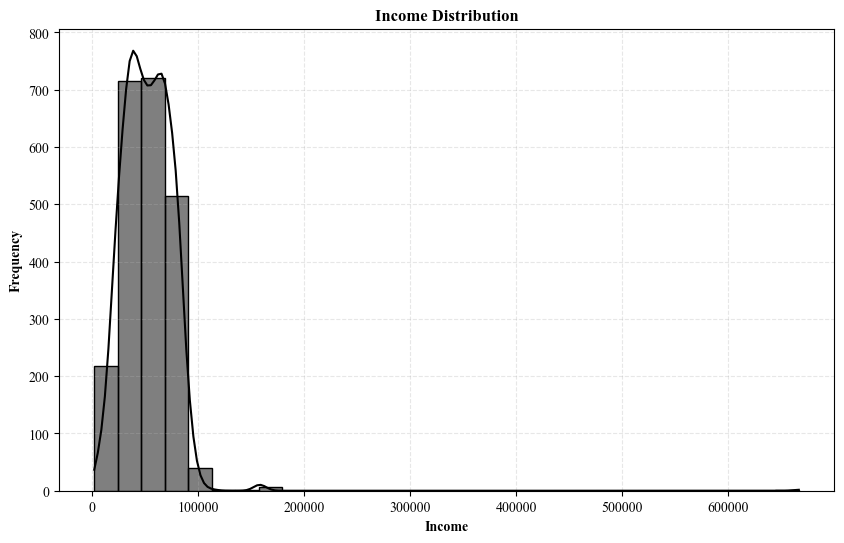

In [20]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.histplot(df['Income'], bins = 30, kde = True, color = 'black', edgecolor = 'black', ax = ax)
ax.set_title('Income Distribution', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Income', fontweight = 'bold')
ax.set_ylabel('Frequency', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

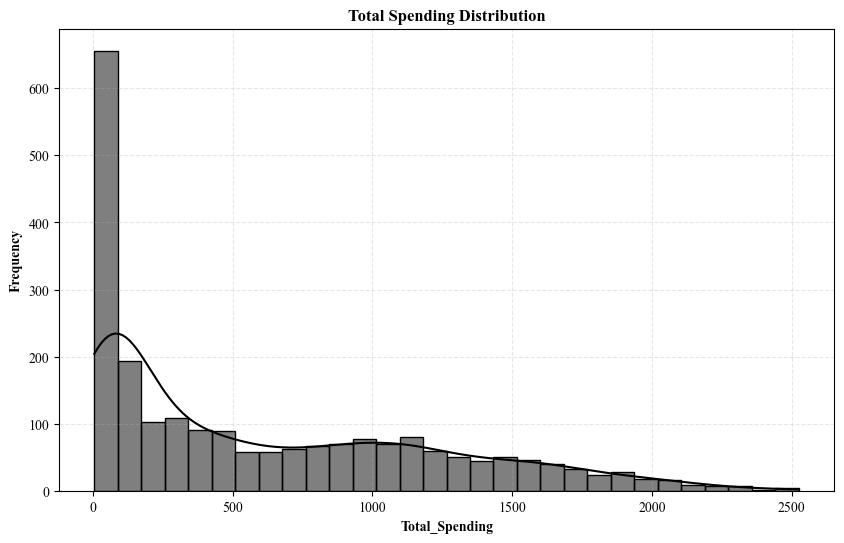

In [21]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.histplot(df['Total_Spending'], bins = 30, kde = True, color = 'black', edgecolor = 'black', ax = ax)
ax.set_title('Total Spending Distribution', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Total_Spending', fontweight = 'bold')
ax.set_ylabel('Frequency', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

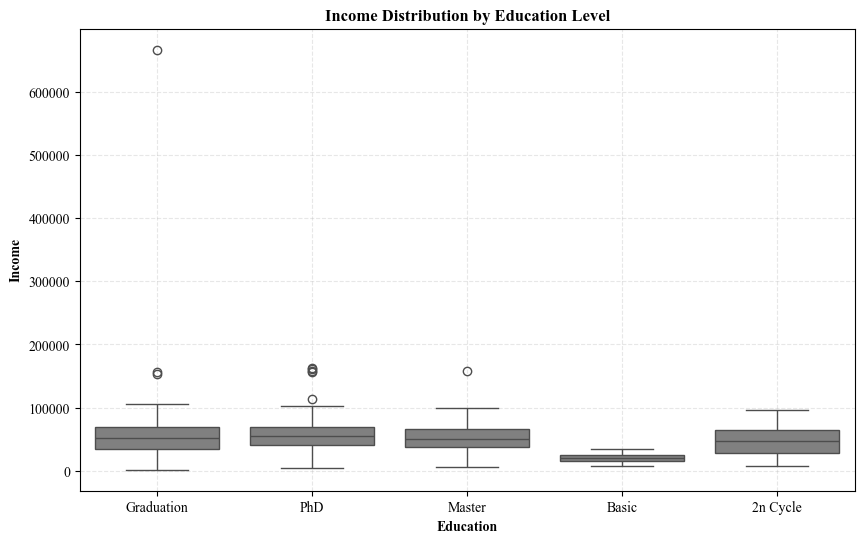

In [22]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.boxplot(x = 'Education', y = 'Income', data = df, color = 'grey', ax = ax)
ax.set_title('Income Distribution by Education Level', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Education', fontweight = 'bold')
ax.set_ylabel('Income', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [23]:
corr = df[['Income', 'Age', 'Recency', 'Total_Spending', 'NumWebPurchases', 'NumStorePurchases']].corr()
corr

,Income,Age,Recency,Total_Spending,NumWebPurchases,NumStorePurchases
Income,1.000000,0.161791,-0.003970,0.667576,0.387878,0.529362
Age,0.161791,1.000000,0.016295,0.113487,0.153051,0.127891
Recency,-0.003970,0.016295,1.000000,0.020066,-0.005641,-0.000434
Total_Spending,0.667576,0.113487,0.020066,1.000000,0.528973,0.675181
NumWebPurchases,0.387878,0.153051,-0.005641,0.528973,1.000000,0.516240
NumStorePurchases,0.529362,0.127891,-0.000434,0.675181,0.516240,1.000000


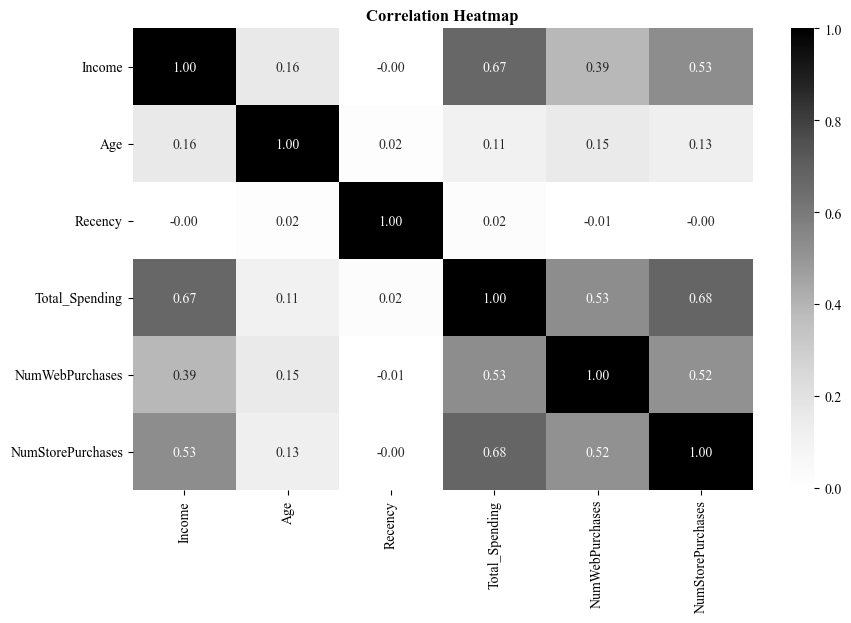

In [24]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.heatmap(corr, annot = True, cmap = 'Greys', fmt = '.2f', ax = ax)
ax.set_title('Correlation Heatmap', fontweight = 'bold', fontsize = 12)
ax.grid(False)

plt.show()

In [25]:
pivot_income = df.pivot_table(values = 'Income', index = 'Education', columns = 'Marital_Status', aggfunc = 'mean')
pivot_income

Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Education,,,,,,,,
2n Cycle,NaN,NaN,49395.130435,46201.100000,53673.944444,44736.410714,51392.200000,NaN
Basic,NaN,NaN,9548.000000,21960.500000,18238.666667,21240.071429,22123.000000,NaN
Graduation,79244.0,34176.0,54526.042017,50800.258741,51322.182927,55758.480702,54976.657143,NaN
Master,65487.0,61331.0,50331.945946,53286.028986,53530.560000,52109.009804,58401.545455,NaN
PhD,NaN,35860.0,53096.615385,58138.031579,53314.614583,56041.422414,60288.083333,48432.0


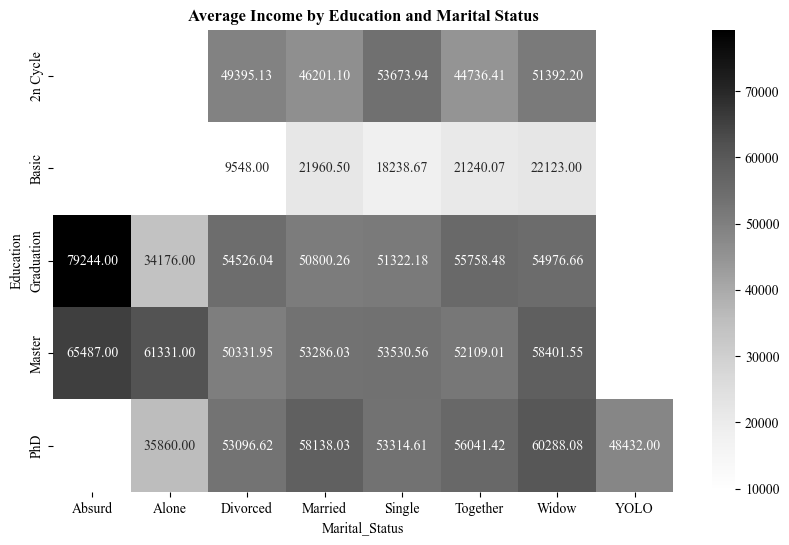

In [26]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.heatmap(pivot_income, annot = True, cmap = 'Greys', fmt = '.2f', ax = ax)
ax.set_title('Average Income by Education and Marital Status', fontweight = 'bold', fontsize = 12)
ax.grid(False)

plt.show()

In [27]:
education_totalspending = df.groupby('Education')['Total_Spending'].mean().sort_values(ascending = False)
education_totalspending

Education
PhD           676.733888
Graduation    621.686380
Master        609.767123
2n Cycle      494.930000
Basic          81.796296
Name: Total_Spending, dtype: float64

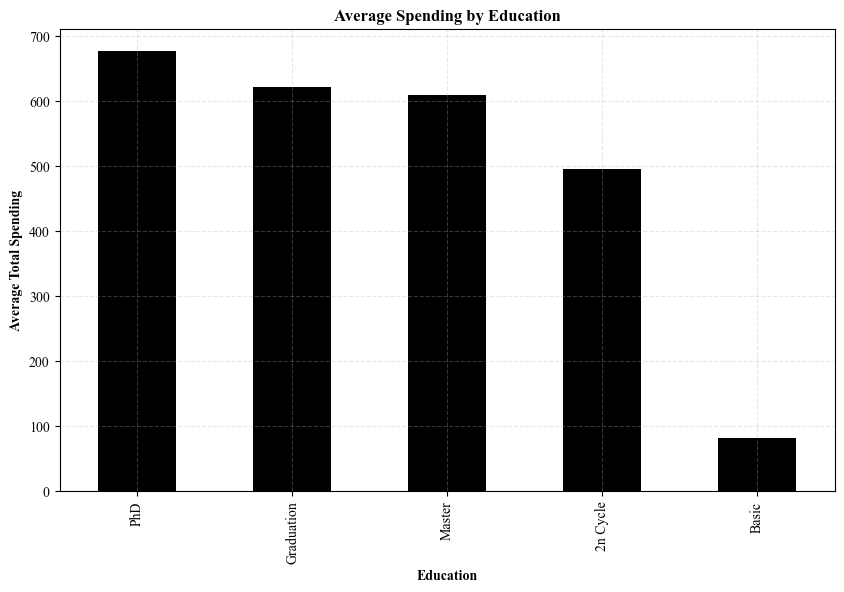

In [28]:
fig, ax = plt.subplots(figsize = (10, 6))
education_totalspending.plot(kind = 'bar', color = 'black', ax = ax)
ax.set_title('Average Spending by Education', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Education', fontweight = 'bold')
ax.set_ylabel('Average Total Spending', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [29]:
df['AcceptedAny'] = df[['AcceptedCmp1', 
                        'AcceptedCmp2', 
                        'AcceptedCmp3', 
                        'AcceptedCmp4',
                        'AcceptedCmp5',
                        'Response']].sum(axis = 1)
df['AcceptedAny'].unique()

array([1, 0, 3, 2, 4, 5])

In [30]:
df['AcceptedAny'] = df['AcceptedAny'].apply(lambda x: 1 if x > 0 else 0)
df['AcceptedAny'].unique()

array([1, 0])

In [31]:
maritalstatus_acceptance = df.groupby('Marital_Status')['AcceptedAny'].mean().sort_values(ascending = False)
maritalstatus_acceptance

Marital_Status
Absurd      0.500000
YOLO        0.500000
Widow       0.342105
Alone       0.333333
Single      0.312102
Divorced    0.297414
Married     0.252042
Together    0.251309
Name: AcceptedAny, dtype: float64

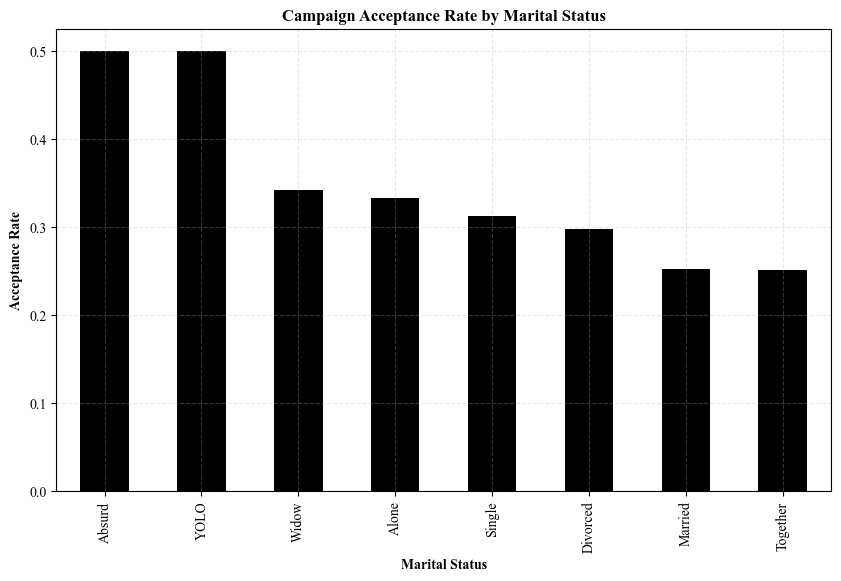

In [32]:
fig, ax = plt.subplots(figsize = (10, 6))
maritalstatus_acceptance.plot(kind = 'bar', color = 'black', ax = ax)
ax.set_title('Campaign Acceptance Rate by Marital Status', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Marital Status', fontweight = 'bold')
ax.set_ylabel('Acceptance Rate', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [33]:
bins = [18, 30, 40, 50, 60, 70, 90]
labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70+']
df['AgeGroup'] = pd.cut(df['Age'], bins = bins, labels = labels)
df['AgeGroup']

0       60-69
1         70+
2       60-69
3       40-49
4       40-49
        ...  
2235    50-59
2236      70+
2237    40-49
2238    60-69
2239      70+
Name: AgeGroup, Length: 2216, dtype: category
Categories (6, object): ['18-29' < '30-39' < '40-49' < '50-59' < '60-69' < '70+']

In [34]:
agegroup_income = df.groupby('AgeGroup')['Income'].mean()
agegroup_income

C:\Users\dilan\AppData\Local\Temp\ipykernel_14076\1796903791.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agegroup_income = df.groupby('AgeGroup')['Income'].mean()


AgeGroup
18-29    10960.500000
30-39    47905.475676
40-49    48057.587649
50-59    50479.321534
60-69    55980.030928
70+      58767.083102
Name: Income, dtype: float64

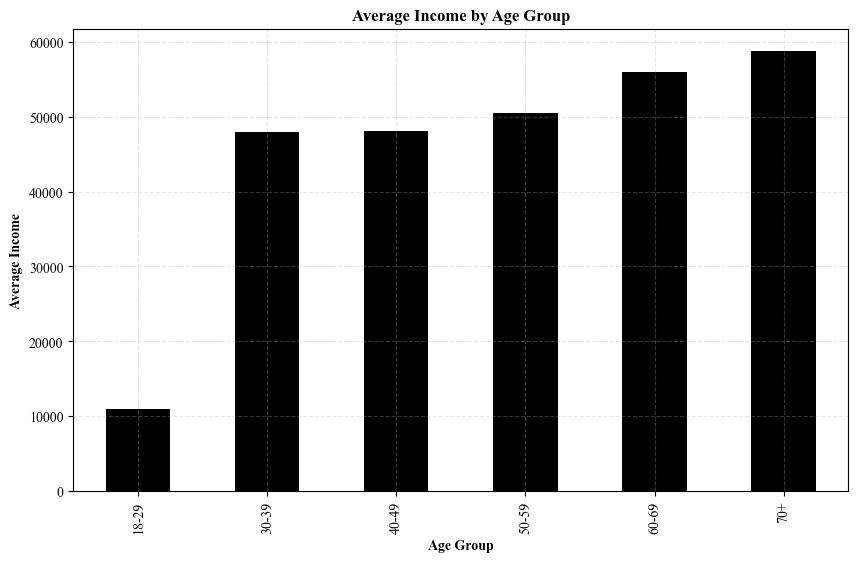

In [35]:
fig, ax = plt.subplots(figsize = (10, 6))
agegroup_income.plot(kind = 'bar', color = 'black', ax = ax)
ax.set_title('Average Income by Age Group', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Age Group', fontweight = 'bold')
ax.set_ylabel('Average Income', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [36]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total Children', 'Total_Spending', 'Customer_Since',
       'AcceptedAny', 'AgeGroup'],
      dtype='object')

In [37]:
features = ['Age', 'Income', 'Total_Spending', 'NumWebPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Recency']
X = df[features].copy()
X

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
0,69,58138.0,1617,8,4,7,58
1,72,46344.0,27,1,2,5,38
2,61,71613.0,776,8,10,4,26
3,42,26646.0,53,2,4,6,26
4,45,58293.0,422,5,6,5,94
...,...,...,...,...,...,...,...
2235,59,61223.0,1341,9,4,5,46
2236,80,64014.0,444,8,5,7,56
2237,45,56981.0,1241,2,13,6,91
2238,70,69245.0,843,6,10,3,8


In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.98644293,  0.2340627 ,  1.67548812, ..., -0.55414289,
         0.69323197,  0.31053212],
       [ 1.23680074, -0.23455948, -0.96235832, ..., -1.16951781,
        -0.1315745 , -0.38050944],
       [ 0.31882209,  0.76947764,  0.28024985, ...,  1.29198186,
        -0.54397773, -0.79513438],
       ...,
       [-1.01641959,  0.18809052,  1.05169551, ...,  2.21504423,
         0.28082874,  1.4507507 ],
       [ 1.06989553,  0.67538765,  0.39140438, ...,  1.29198186,
        -0.95638097, -1.41707178],
       [ 1.23680074,  0.02470453, -0.7218    , ..., -0.55414289,
         0.69323197, -0.31140528]], shape=(2216, 7))

In [41]:
from sklearn.cluster import KMeans

wcss = []

for i in range(2, 10):
    kmeans = KMeans(n_clusters = i)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

wcss

[10218.648106906196,
 9007.786818672808,
 8158.801654022354,
 7991.192729718545,
 7260.204741491039,
 6736.935789155873,
 6447.999830726489,
 6219.279906551754]

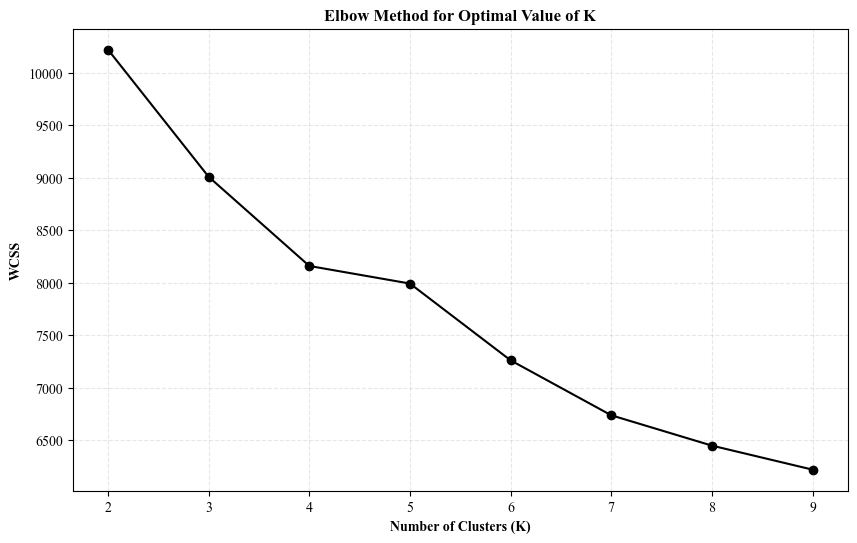

In [42]:
fig, ax = plt.subplots(figsize = (10, 6))
ax.plot(range(2, 10), wcss, marker = 'o', color = 'black')
ax.set_title('Elbow Method for Optimal Value of K', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Number of Clusters (K)', fontweight = 'bold')
ax.set_ylabel('WCSS', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [43]:
kmeans = KMeans(n_clusters = 6)
df['Cluster'] = kmeans.fit_predict(X_scaled)
df['Cluster']

0       4
1       2
2       4
3       2
4       5
       ..
2235    4
2236    0
2237    3
2238    1
2239    0
Name: Cluster, Length: 2216, dtype: int32

In [44]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Z_CostContact,Z_Revenue,Response,Age,Total Children,Total_Spending,Customer_Since,AcceptedAny,AgeGroup,Cluster
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,11,1,69,0,1617,5049,1,60-69,4
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,3,11,0,72,2,27,4499,0,70+,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,3,11,0,61,0,776,4698,0,60-69,4
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,3,11,0,42,1,53,4525,0,40-49,2
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,3,11,0,45,1,422,4547,0,40-49,5


In [45]:
cluster_summaries = df.groupby('Cluster')[features].mean()
cluster_summaries

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,62.979239,53571.176471,567.179931,5.795848,6.294118,6.318339,24.612457
1,70.752542,74058.213559,1184.894915,4.413559,8.247458,2.403390,53.993220
2,51.639376,31642.516569,79.428850,1.846004,2.974659,6.633528,27.196881
3,47.172308,78498.036923,1304.206154,4.572308,8.640000,2.649231,47.815385
4,59.580205,62424.064846,1032.273038,8.372014,8.679181,6.146758,60.549488
5,56.602794,36758.367265,129.241517,2.375250,3.445110,6.361277,76.522954


In [46]:
df['Cluster'].value_counts()

Cluster
2    513
5    501
3    325
1    295
4    293
0    289
Name: count, dtype: int64

In [47]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
pca_data = pca.fit_transform(X_scaled)
df['PCA1'], df['PCA2'] = pca_data[:, 0], pca_data[:, 1]
pca_data

array([[ 1.1075188 , -0.21175951],
       [-1.33673385,  0.269839  ],
       [ 1.88227676, -1.01416098],
       ...,
       [ 1.1535966 ,  1.15056999],
       [ 1.88768024, -1.16073698],
       [-0.84182091, -0.15963623]], shape=(2216, 2))

In [48]:
df['PCA1']

0       1.107519
1      -1.336734
2       1.882277
3      -1.784359
4       0.020363
          ...   
2235    1.248177
2236    0.508708
2237    1.153597
2238    1.887680
2239   -0.841821
Name: PCA1, Length: 2216, dtype: float64

In [49]:
df['PCA2']

0      -0.211760
1       0.269839
2      -1.014161
3      -0.704928
4       1.235265
          ...   
2235   -0.535766
2236   -0.141328
2237    1.150570
2238   -1.160737
2239   -0.159636
Name: PCA2, Length: 2216, dtype: float64

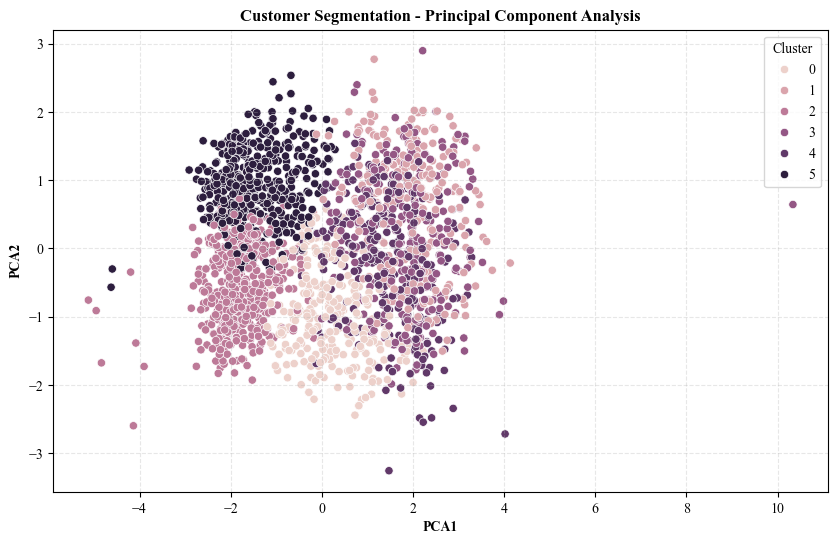

In [52]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.scatterplot(x = 'PCA1', y = 'PCA2', hue = 'Cluster', data = df, ax = ax)
ax.set_title('Customer Segmentation - Principal Component Analysis', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('PCA1', fontweight = 'bold')
ax.set_ylabel('PCA2', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [53]:
import joblib

joblib.dump(kmeans, 'Customer Segmentation - K-Means Model.pkl')
joblib.dump(scaler, 'Customer Segmentation - Scaler.pkl')

['Customer Segmentation - Scaler.pkl']